# E-Commerce Sales, Customer Satisfaction, Delivery & Seller Performance Analysis

## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Olist Brazilian E-Commerce dataset.

### Objectives

- Analyze sales and revenue trends
- Explore product category performance
- Evaluate delivery performance
- Investigate the relationship between delivery and customer satisfaction
- Analyze payment behavior
- Identify potential business patterns for further analysis

### Tools

- Python
- Pandas
- NumPy
- Matplotlib
- MySQL

## 1. Import Libraries

Import the Python libraries required for data loading, manipulation, analysis, visualization, and MySQL connectivity.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

## 2. Connect to MySQL

The analysis uses MySQL as the main data source.

The database contains the original Olist tables and the `cleaned_orders` analytical view created during the SQL phase.

In [ ]:
from getpass import getpass
from sqlalchemy import create_engine, URL

engine = create_engine(
    URL.create(
        drivername="mysql+pymysql",
        username="root",
        password=getpass("Enter your MySQL password: "),
        host="localhost",
        port=3306,
        database="olist_project",
    )
)

Test the connection

In [84]:
pd.read_sql(
    "SELECT 1",
    con=engine
)

,1
0,1


## 3. Load Data

The datasets are loaded directly from MySQL rather than re-importing the original CSV files.

This keeps MySQL as the central data source for the project and allows Python to perform EDA on the same data used for the SQL analysis.

In [85]:
cleaned_orders = pd.read_sql(
    "SELECT * FROM cleaned_orders",
    con=engine
)

orders = pd.read_sql(
    "SELECT * FROM orders",
    con=engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    con=engine
)

payments = pd.read_sql(
    "SELECT * FROM payments",
    con=engine
)

reviews = pd.read_sql(
    "SELECT * FROM reviews",
    con=engine
)

customers = pd.read_sql(
    "SELECT * FROM customers",
    con=engine
)

products = pd.read_sql(
    "SELECT * FROM products",
    con=engine
)

sellers = pd.read_sql(
    "SELECT * FROM sellers",
    con=engine
)

category_translation = pd.read_sql(
    "SELECT * FROM category_translation",
    con=engine
)

## 4. Dataset Overview

Before performing analysis, inspect the size and structure of each dataset.

In [86]:
tables = {
    "cleaned_orders": cleaned_orders,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

cleaned_orders: (96470, 8)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 8)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (73, 2)


## 5. Data Types

Check the data types of the columns to ensure that dates, numeric values, and categorical fields are stored appropriately.

In [87]:
for name, df in tables.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    df.info()


CLEANED_ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  str           
 1   customer_id                    96470 non-null  str           
 2   order_purchase_timestamp       96470 non-null  datetime64[us]
 3   order_delivered_customer_date  96470 non-null  datetime64[us]
 4   order_estimated_delivery_date  96470 non-null  datetime64[us]
 5   delivery_days                  96470 non-null  int64         
 6   delay_days                     96470 non-null  int64         
 7   delivery_status                96470 non-null  str           
dtypes: datetime64[us](3), int64(2), str(3)
memory usage: 5.9 MB

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Co

## 6. Missing Value Analysis

Check for missing values before performing analysis.

Missing values may affect calculations, joins, and visualizations.

### Observation

Missing values are concentrated in several fields such as product descriptions
and review comments. These fields are not required for the current business
analysis, so they will not be used in the main calculations.

In [88]:
missing_values = {}

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if len(missing) > 0:
        missing_values[name] = missing

missing_values

{'orders': order_approved_at                 160
 order_delivered_carrier_date     1783
 order_delivered_customer_date    2965
 dtype: int64,
 'reviews': review_comment_title      87656
 review_comment_message    58247
 dtype: int64,
 'products': product_category_name         610
 product_name_lenght           610
 product_description_lenght    610
 product_photos_qty            610
 product_weight_g                2
 product_length_cm               2
 product_height_cm               2
 product_width_cm                2
 dtype: int64}

## 7. Duplicate Check

Check for duplicate records in the main analytical datasets.

In [89]:
print(
    "Duplicate order IDs in cleaned_orders:",
    cleaned_orders["order_id"].duplicated().sum()
)

print(
    "Duplicate order IDs in orders:",
    orders["order_id"].duplicated().sum()
)

Duplicate order IDs in cleaned_orders: 0
Duplicate order IDs in orders: 0


# 8. Sales Exploratory Data Analysis

This section explores marketplace revenue, order volume, product category performance, and average order value.

### Key questions

1. How has marketplace revenue changed over time?
2. Which product categories generate the highest revenue?
3. What is the average customer spending per order?
4. Is revenue growth driven by more orders or higher spending?

## 8.1 Monthly Revenue Trend

Calculate total revenue by month using payment values.

Payment records are first aggregated at the order level because a single order can contain multiple payment records.

In [90]:
order_revenue = (
    payments
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue = order_revenue.merge(
    cleaned_orders[
        ["order_id", "order_purchase_timestamp"]
    ],
    on="order_id",
    how="inner"
)

monthly_revenue["month"] = (
    pd.to_datetime(
        monthly_revenue["order_purchase_timestamp"]
    )
    .dt.to_period("M")
)

revenue = (
    monthly_revenue
    .groupby("month")["payment_value"]
    .sum()
)

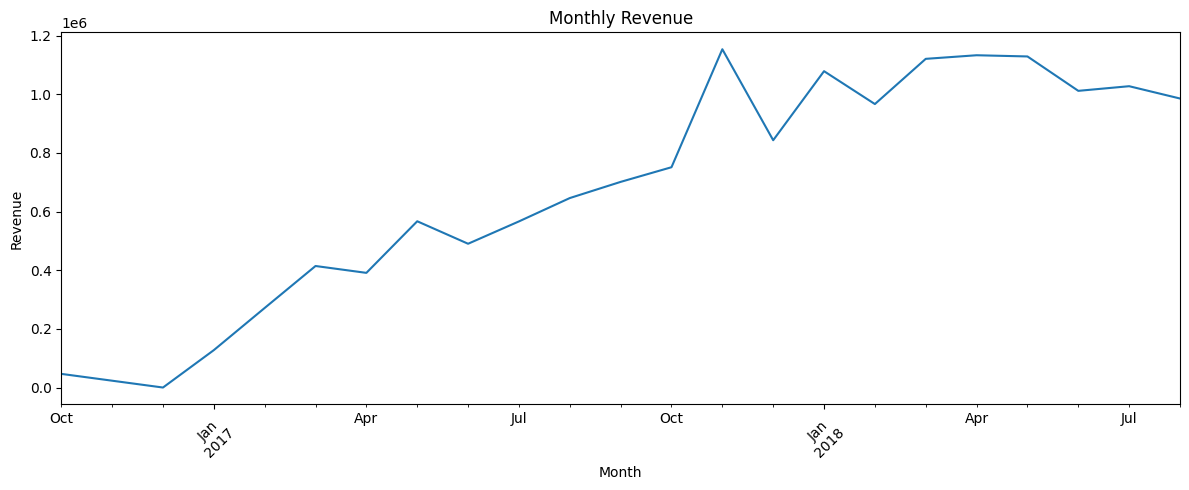

In [91]:
plt.figure(figsize=(12, 5))

revenue.plot(
    kind="line",
    title="Monthly Revenue"
)

plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8.2 Monthly Order Volume

Analyze the number of unique orders placed each month.

Comparing order volume with revenue helps determine whether revenue changes are driven by changes in the number of orders.

In [92]:
monthly_orders = (
    monthly_revenue
    .groupby("month")["order_id"]
    .nunique()
)

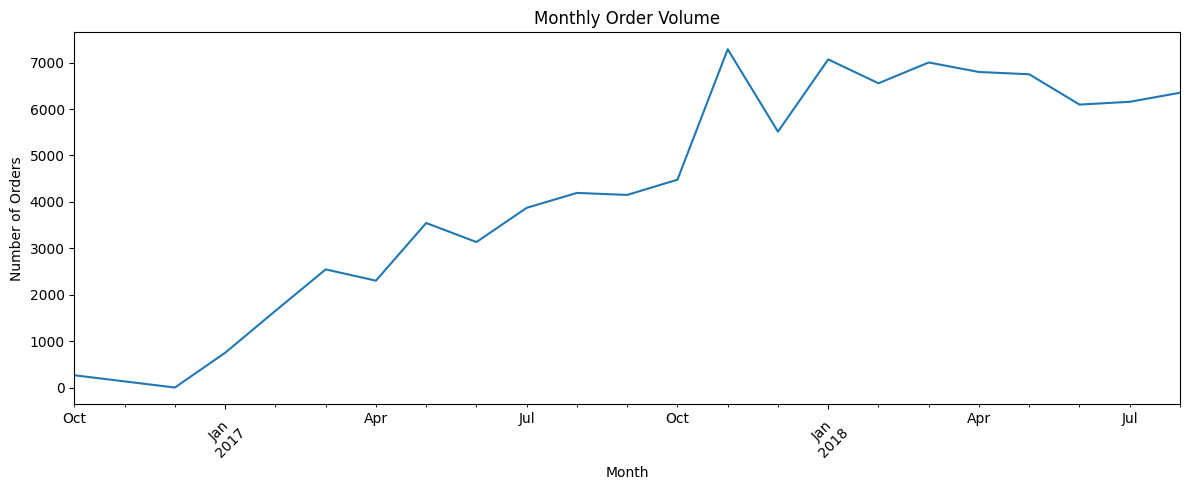

In [93]:
plt.figure(figsize=(12, 5))

monthly_orders.plot(
    kind="line",
    title="Monthly Order Volume"
)

plt.ylabel("Number of Orders")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8.3 Monthly Average Order Value

Average Order Value (AOV) measures the average amount spent per order.

A monthly AOV analysis helps determine whether changes in revenue are driven primarily by changes in order volume or by changes in the average amount spent per order.

AOV is calculated as:

**AOV = Total Revenue / Number of Unique Orders**

This provides additional context when interpreting monthly revenue and order-volume trends.


In [94]:
average_order_value = (
    order_revenue["payment_value"].sum()
    / order_revenue["order_id"].nunique()
)

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 160.99


In [95]:
monthly_aov = (
    monthly_revenue
    .groupby("month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_aov["aov"] = (
    monthly_aov["total_revenue"]
    / monthly_aov["total_orders"]
)

monthly_aov.round(2)

,total_revenue,total_orders,aov
month,,,
2016-10,46566.71,265,175.72
2016-12,19.62,1,19.62
2017-01,127545.67,750,170.06
2017-02,271298.65,1653,164.13
2017-03,414369.39,2546,162.75
2017-04,390952.18,2303,169.76
2017-05,566872.73,3545,159.91
2017-06,490225.60,3135,156.37
2017-07,566403.93,3872,146.28


## 8.4 Product Category Revenue

Analyze which product categories generate the highest revenue.

For this analysis, order-item revenue is defined as:

Order Item Value = Product Price + Freight Value

This represents the gross value associated with each order item,
including the shipping charge.

In [96]:
category_revenue = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "product_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="inner"
    )
    .merge(
        category_translation[
            [
                "product_category_name",
                "product_category_name_english"
            ]
        ],
        on="product_category_name",
        how="left"
    )
)

Create revenue:

In [97]:
category_revenue["item_revenue"] = (
    category_revenue["price"]
    + category_revenue["freight_value"]
)

Aggregate:

In [98]:
category_summary = (
    category_revenue
    .groupby("product_category_name_english")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

category_summary.head(10)

,total_orders,total_revenue
product_category_name_english,,
health_beauty,8647,1412089.53
watches_gifts,5493,1264016.98
bed_bath_table,9272,1225209.26
sports_leisure,7529,1118062.91
computers_accessories,6529,1032603.65
furniture_decor,6307,880329.92
housewares,5743,758392.25
cool_stuff,3559,691680.89
auto,3809,669319.92


### Top 10 Product Categories by Revenue

In [99]:
top_categories = (
    category_summary["total_revenue"]
    .head(10)
    .sort_values()
)

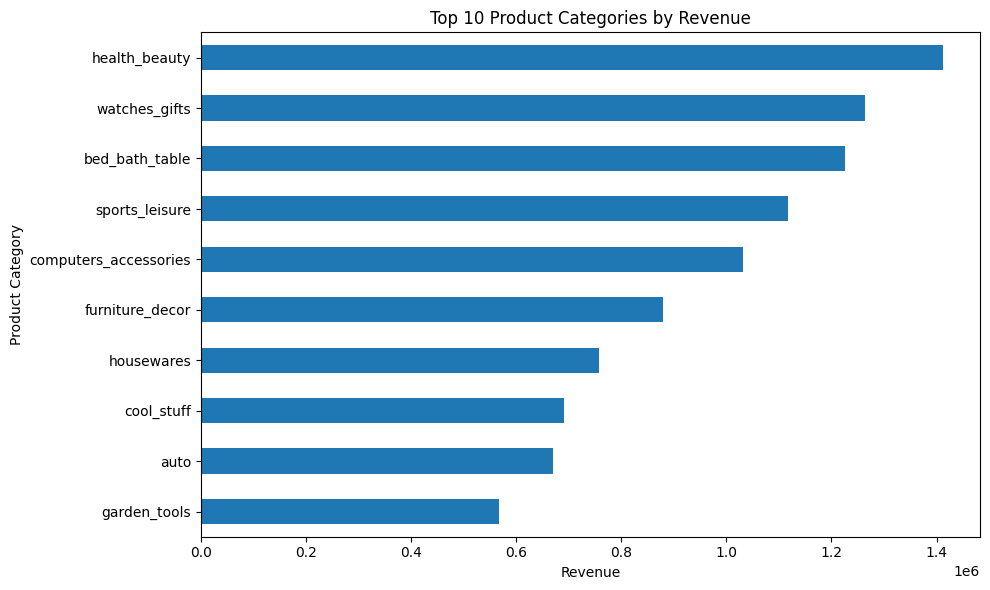

In [100]:
plt.figure(figsize=(10, 6))

top_categories.plot(
    kind="barh",
    title="Top 10 Product Categories by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

# 9. Delivery Exploratory Data Analysis

This section explores delivery performance and investigates whether delivery performance is associated with customer satisfaction.

### Key questions

1. How many orders were delivered late?
2. How long do deliveries take?
3. Which states have the highest late-delivery rates?
4. Are there unusual delivery times or outliers?
5. Is delivery performance associated with customer review scores?

## 9.1 Delivery Status Distribution

Analyze the number and percentage of orders that were delivered on time versus late.

In [101]:
delivery_summary = (
    cleaned_orders
    .groupby("delivery_status")["order_id"]
    .count()
)

delivery_percentage = (
    delivery_summary
    / delivery_summary.sum()
    * 100
)

delivery_summary

delivery_status
Late        7826
On Time    88644
Name: order_id, dtype: int64

In [102]:
delivery_percentage.round(2)

delivery_status
Late        8.11
On Time    91.89
Name: order_id, dtype: float64

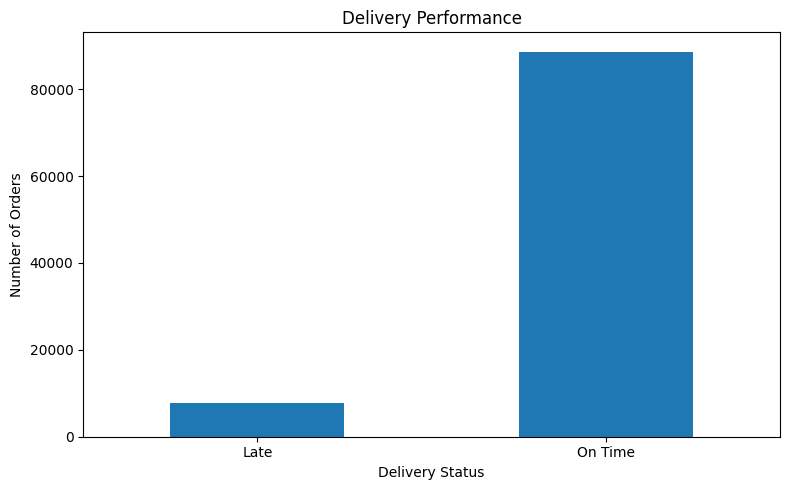

In [103]:
plt.figure(figsize=(8, 5))

delivery_summary.plot(
    kind="bar",
    title="Delivery Performance"
)

plt.ylabel("Number of Orders")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.2 Average Delivery Time

Compare actual delivery time and delivery delay between late and on-time orders.

In [104]:
delivery_time_summary = (
    cleaned_orders
    .groupby("delivery_status")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delay_days", "mean")
    )
    .round(2)
)

delivery_time_summary

,average_delivery_days,average_delay_days
delivery_status,,
Late,31.48,8.87
On Time,10.82,-13.71


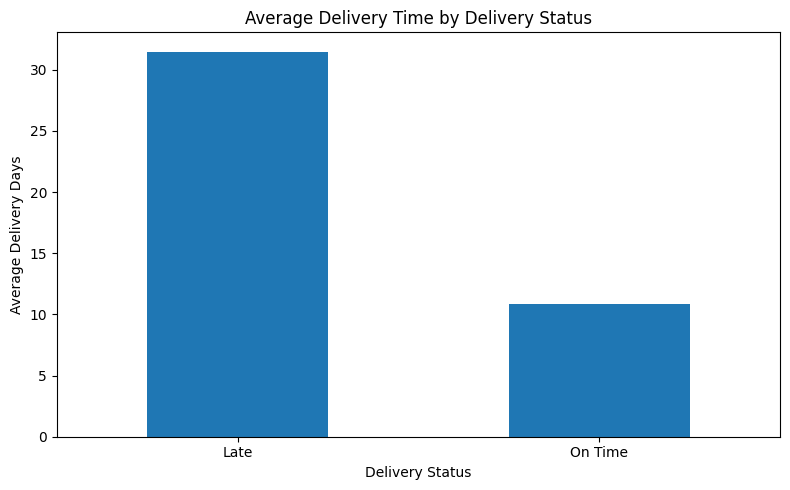

In [105]:
plt.figure(figsize=(8, 5))

delivery_time_summary[
    "average_delivery_days"
].plot(
    kind="bar",
    title="Average Delivery Time by Delivery Status"
)

plt.ylabel("Average Delivery Days")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.3 Late Delivery Rate by State

Analyze whether delivery performance varies across customer states.

The late-delivery rate is calculated as:

Late Delivery Rate = Late Orders / Total Orders × 100

In [109]:
delivery_state = (
    cleaned_orders[
        [
            "order_id",
            "customer_id",
            "delivery_status"
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

delivery_state["is_late"] = (
    delivery_state["delivery_status"] == "Late"
)

In [110]:
state_delivery = (
    delivery_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum")
    )
)

state_delivery["late_delivery_rate"] = (
    state_delivery["late_orders"]
    / state_delivery["total_orders"]
    * 100
)

state_delivery = state_delivery.sort_values(
    "late_delivery_rate",
    ascending=False
)

state_delivery.head(10)

,total_orders,late_orders,late_delivery_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


In [111]:
state_delivery_filtered = state_delivery[
    state_delivery["total_orders"] >= 100
]

top_late_states = (
    state_delivery_filtered
    .sort_values("late_delivery_rate", ascending=False)
    .head(10)
)

top_late_states

,total_orders,late_orders,late_delivery_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


### Top 10 States by Late Delivery Rate

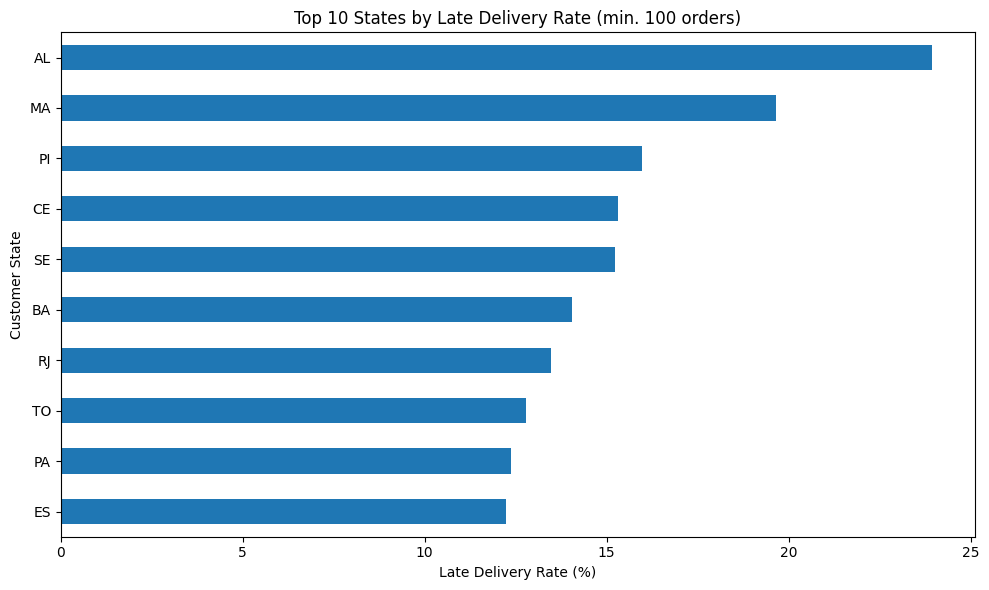

In [113]:
top_late_states_chart = (
    state_delivery_filtered["late_delivery_rate"]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_late_states_chart.plot(
    kind="barh",
    title="Top 10 States by Late Delivery Rate (min. 100 orders)"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

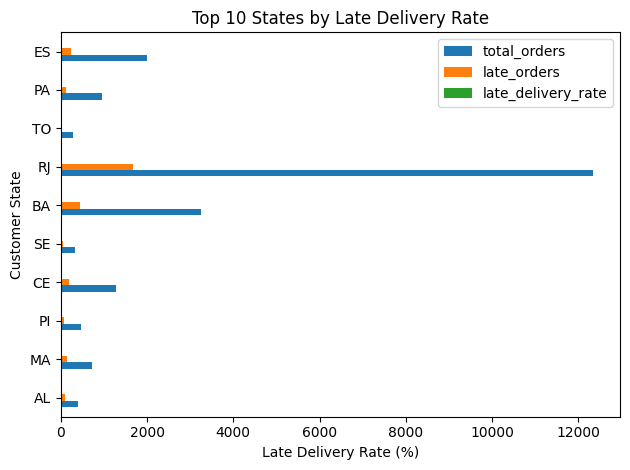

In [114]:
plt.figure(figsize=(10, 6))

top_late_states.plot(
    kind="barh",
    title="Top 10 States by Late Delivery Rate"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

## 9.4 Delivery Time Distribution

Examine the distribution of delivery times to identify common delivery durations and potential outliers.

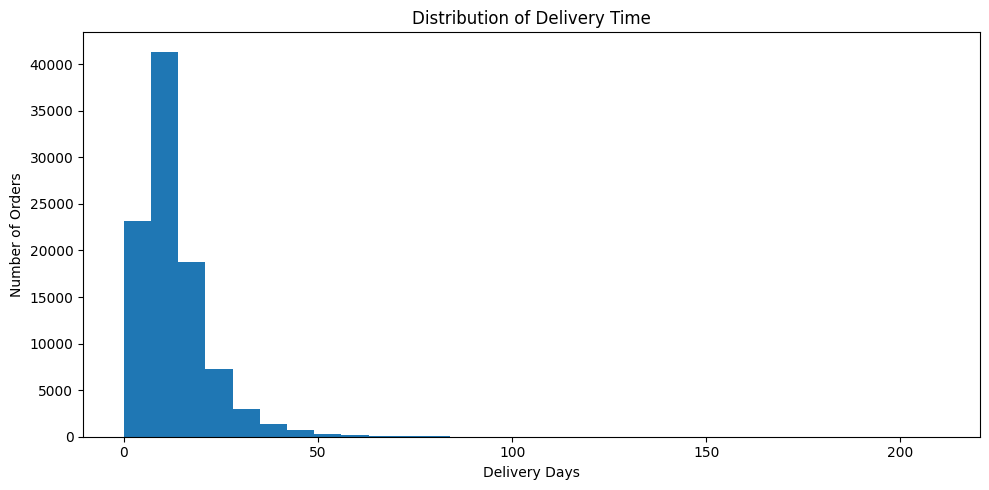

In [115]:
plt.figure(figsize=(10, 5))

cleaned_orders["delivery_days"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Delivery Time"
)

plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [116]:
cleaned_orders["delivery_days"].describe()

count    96470.000000
mean        12.496849
std          9.555071
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: delivery_days, dtype: float64

## 9.5 Delivery Performance vs Customer Satisfaction

Investigate whether late delivery is associated with lower customer review scores.

In [117]:
delivery_review = (
    cleaned_orders[
        [
            "order_id",
            "delivery_days",
            "delay_days",
            "delivery_status"
        ]
    ]
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Calculate:

In [118]:
review_by_delivery = (
    delivery_review
    .groupby("delivery_status")["review_score"]
    .mean()
    .round(2)
)

review_by_delivery

delivery_status
Late       2.57
On Time    4.29
Name: review_score, dtype: float64

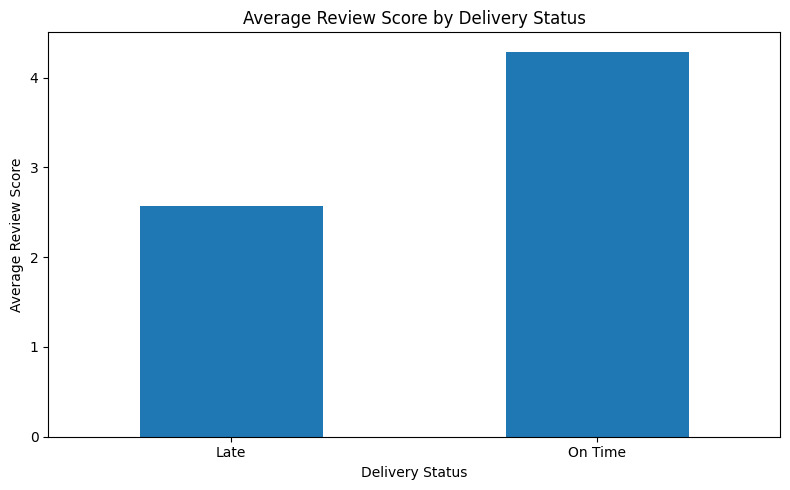

In [119]:
plt.figure(figsize=(8, 5))

review_by_delivery.plot(
    kind="bar",
    title="Average Review Score by Delivery Status"
)

plt.ylabel("Average Review Score")
plt.xlabel("Delivery Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9.6 Delivery Time vs Review Score

Explore whether longer delivery times are associated with lower customer review scores.

A scatter plot is used to examine the relationship between delivery duration and review score.

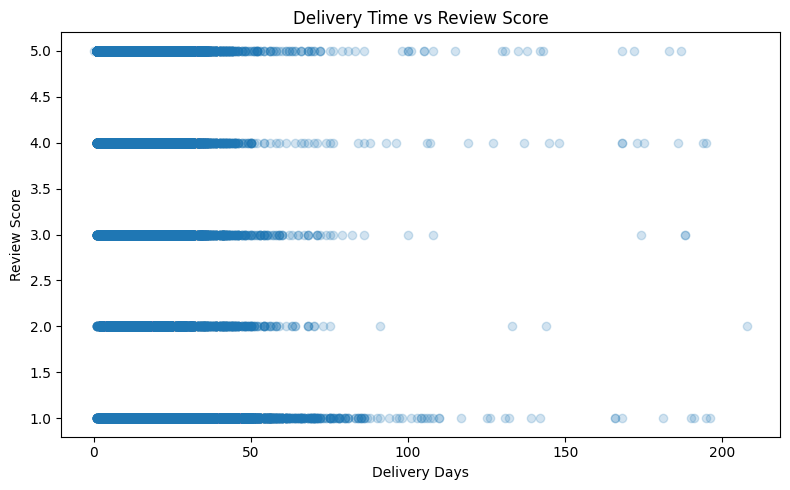

In [120]:
plt.figure(figsize=(8, 5))

plt.scatter(
    delivery_review["delivery_days"],
    delivery_review["review_score"],
    alpha=0.2
)

plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

Correlation:

In [121]:
delivery_review[
    [
        "delivery_days",
        "review_score"
    ]
].corr()

,delivery_days,review_score
delivery_days,1.000000,-0.333629
review_score,-0.333629,1.000000


# 10. Payment Exploratory Data Analysis

This section examines customer payment behavior, including payment method usage and payment value.

In [122]:
payment_summary = (
    payments
    .groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        total_revenue=("payment_value", "sum")
    )
    .sort_values(
        "transactions",
        ascending=False
    )
)

payment_summary

,transactions,total_revenue
payment_type,,
credit_card,76795,12542084.19
boleto,19784,2869361.27
voucher,5775,379436.87
debit_card,1529,217989.79
not_defined,3,0.00


## 10.1 Payment Method Usage

Analyze which payment methods are most frequently used by customers.

In [123]:
payment_summary

,transactions,total_revenue
payment_type,,
credit_card,76795,12542084.19
boleto,19784,2869361.27
voucher,5775,379436.87
debit_card,1529,217989.79
not_defined,3,0.00


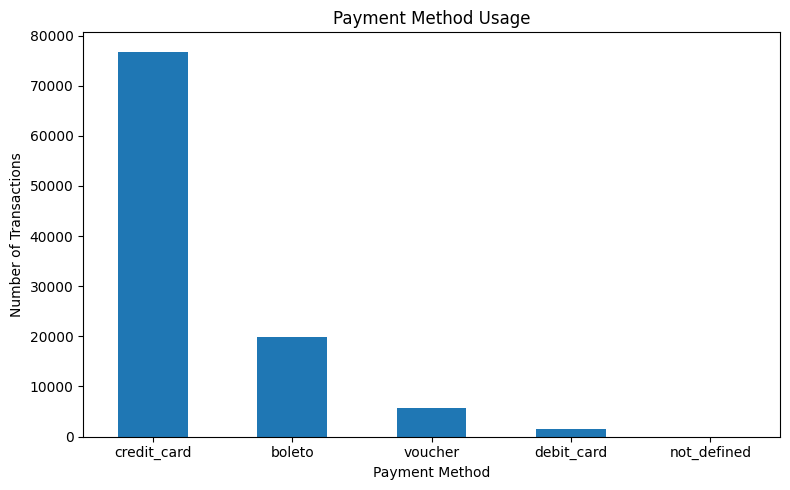

In [70]:
plt.figure(figsize=(8, 5))

payment_summary["transactions"].plot(
    kind="bar",
    title="Payment Method Usage"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10.2 Revenue by Payment Method

Compare the total revenue associated with each payment method.

In [124]:
payment_revenue = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

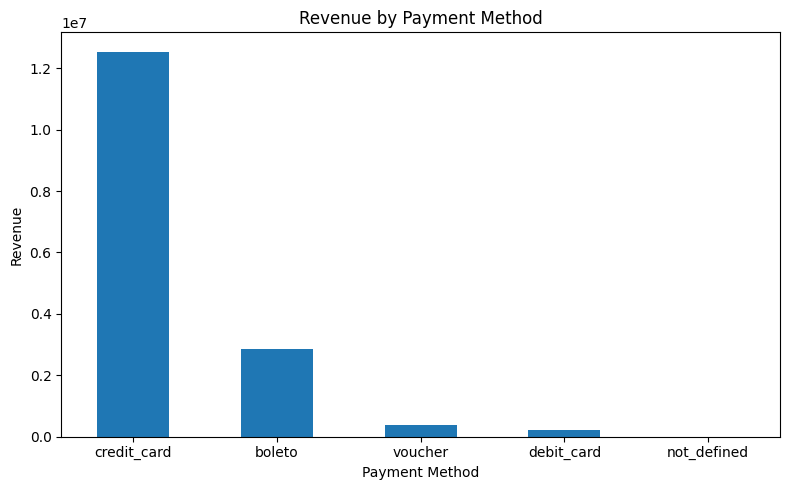

In [125]:
plt.figure(figsize=(8, 5))

payment_revenue.plot(
    kind="bar",
    title="Revenue by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 10.3 Installment Payment Behavior

Analyze whether customers using installment payments have higher average
payment values than customers making single payments.

In [126]:
payments["payment_group"] = np.where(
    payments["payment_installments"] == 1,
    "Single Payment",
    "Installment"
)

In [127]:
installment_summary = (
    payments
    .groupby("payment_group")
    .agg(
        transactions=("order_id", "count"),
        average_payment_value=("payment_value", "mean")
    )
    .round(2)
)

installment_summary

,transactions,average_payment_value
payment_group,,
Installment,51340,196.76
Single Payment,52546,112.42


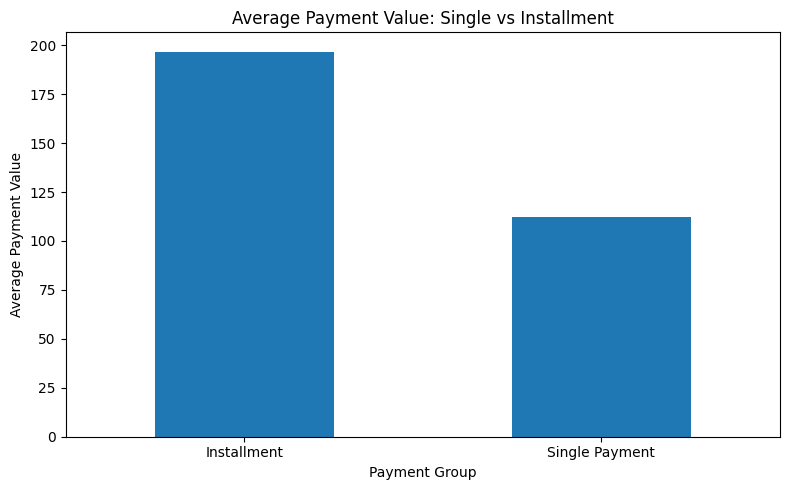

In [128]:
plt.figure(figsize=(8, 5))

installment_summary["average_payment_value"].plot(
    kind="bar",
    title="Average Payment Value: Single vs Installment"
)

plt.xlabel("Payment Group")
plt.ylabel("Average Payment Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 11. Customer Satisfaction Exploratory Data Analysis

This section explores customer satisfaction using review scores and investigates
whether delivery performance and product categories are associated with customer
satisfaction.

### Key questions

1. What is the overall average customer review score?
2. How are review scores distributed?
3. Does late delivery affect customer satisfaction?
4. Which product categories receive the most negative reviews?
5. Are there categories with high revenue but relatively low satisfaction?

## 11.1 Overall Customer Satisfaction

Calculate the average customer review score across all reviewed orders.

The review score ranges from 1 to 5, where higher scores indicate greater
customer satisfaction.

In [129]:
average_review_score = reviews["review_score"].mean()

print(f"Average Customer Review Score: {average_review_score:.2f}")

Average Customer Review Score: 4.09


In [130]:
review_summary = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_summary

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

## 11.2 Review Score Distribution

Examine how customer reviews are distributed across the 1–5 rating scale.

This helps identify whether customer feedback is concentrated around positive,
neutral, or negative ratings.

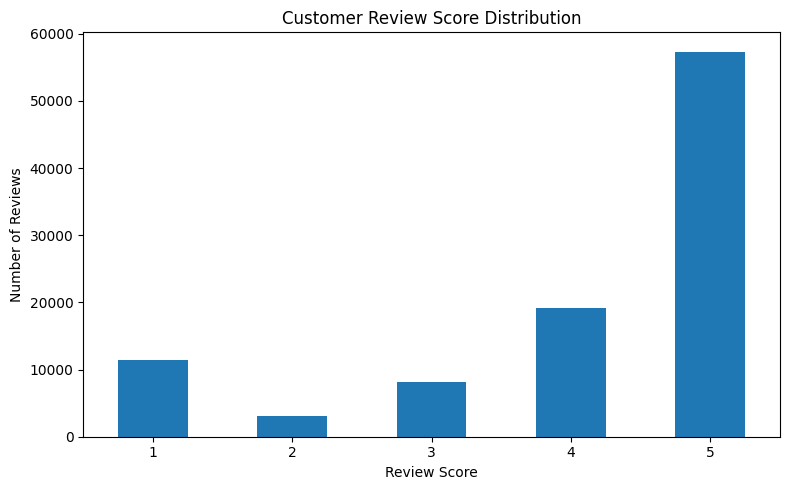

In [131]:
plt.figure(figsize=(8, 5))

review_summary.plot(
    kind="bar",
    title="Customer Review Score Distribution"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 11.3 Negative Reviews by Product Category

Identify product categories with the highest number of negative reviews.

A negative review is defined as a review score of 1 or 2.

This analysis can help identify product categories that may require further
investigation.

In [132]:
negative_reviews = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "product_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="inner"
    )
    .merge(
        category_translation[
            [
                "product_category_name",
                "product_category_name_english"
            ]
        ],
        on="product_category_name",
        how="left"
    )
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Create the negative-review flag:

In [133]:
negative_reviews["is_negative"] = (
    negative_reviews["review_score"] <= 2
)

Aggregate:

In [134]:
category_review_summary = (
    negative_reviews
    .groupby("product_category_name_english")
    .agg(
        total_reviews=("order_id", "count"),
        negative_reviews=("is_negative", "sum")
    )
)

category_review_summary["negative_review_rate"] = (
    category_review_summary["negative_reviews"]
    / category_review_summary["total_reviews"]
    * 100
)

# exclude categories with too few reviews to be meaningful
category_review_summary_filtered = category_review_summary[
    category_review_summary["total_reviews"] >= 20
].sort_values("negative_review_rate", ascending=False)

category_review_summary_filtered.head(10)

,total_reviews,negative_reviews,negative_review_rate
product_category_name_english,,,
home_comfort_2,27,7,25.925926
office_furniture,1664,423,25.420673
fashion_male_clothing,124,31,25.000000
fixed_telephony,253,58,22.924901
audio,359,78,21.727019
diapers_and_hygiene,37,8,21.621622
party_supplies,42,9,21.428571
home_confort,430,85,19.767442
furniture_mattress_and_upholstery,37,7,18.918919


## 11.4 Visualize Negative Reviews
### Top 10 Product Categories by Negative Reviews

In [135]:
top_negative_categories = (
    category_review_summary_filtered[
        "negative_review_rate"
    ]
    .head(10)
    .sort_values()
)

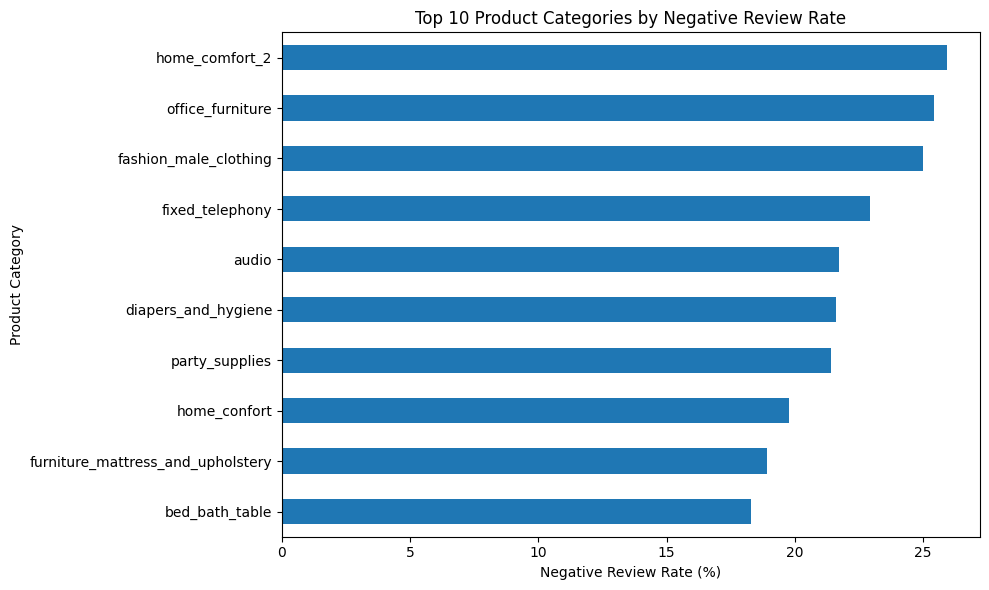

In [136]:
plt.figure(figsize=(10, 6))

top_negative_categories.plot(
    kind="barh",
    title="Top 10 Product Categories by Negative Review Rate"
)

plt.xlabel("Negative Review Rate (%)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## 11.5 High Revenue but Low Customer Satisfaction

Identify product categories that generate substantial revenue but receive
relatively low customer review scores.

This helps identify categories that may generate strong sales while presenting
potential customer experience issues.

In [137]:
category_reviews = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "product_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="inner"
    )
    .merge(
        category_translation[
            [
                "product_category_name",
                "product_category_name_english"
            ]
        ],
        on="product_category_name",
        how="left"
    )
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

In [138]:
category_satisfaction = (
    category_reviews
    .groupby("product_category_name_english")
    .agg(
        average_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
    .round(2)
)

In [139]:
category_performance = category_summary.merge(
    category_satisfaction,
    left_index=True,
    right_index=True,
    how="inner"
)

category_performance = category_performance.sort_values(
    "total_revenue",
    ascending=False
)

category_performance.head(10)

,total_orders,total_revenue,average_review_score,total_reviews
product_category_name_english,,,,
health_beauty,8647,1412089.53,4.19,9456
watches_gifts,5493,1264016.98,4.07,5823
bed_bath_table,9272,1225209.26,3.92,10985
sports_leisure,7529,1118062.91,4.17,8435
computers_accessories,6529,1032603.65,3.99,7671
furniture_decor,6307,880329.92,3.95,8159
housewares,5743,758392.25,4.11,6780
cool_stuff,3559,691680.89,4.19,3698
auto,3809,669319.92,4.12,4116


In [140]:
top_revenue_categories = category_performance[
    category_performance["total_revenue"] >=
    category_performance["total_revenue"].quantile(0.75)
]

satisfaction_threshold = top_revenue_categories["average_review_score"].quantile(0.25)

high_revenue_low_satisfaction = (
    top_revenue_categories[
        top_revenue_categories["average_review_score"] <= satisfaction_threshold
    ]
    .sort_values("average_review_score")
)

high_revenue_low_satisfaction

,total_orders,total_revenue,average_review_score,total_reviews
product_category_name_english,,,,
office_furniture,1254,335211.36,3.52,1664
bed_bath_table,9272,1225209.26,3.92,10985
furniture_decor,6307,880329.92,3.95,8159
computers_accessories,6529,1032603.65,3.99,7671
telephony,4093,379202.62,4.00,4408


# 12. Seller Performance Exploratory Data Analysis

This section evaluates seller performance based on revenue generation,
order volume, and customer satisfaction.

### Key questions

1. Which sellers generate the highest revenue?
2. Which sellers handle the highest number of orders?
3. Which sellers generate high revenue but have relatively low customer satisfaction?
4. Are there sellers that may require further investigation?

## 12.1 Top Sellers by Revenue

Identify the sellers generating the highest revenue from delivered orders.

Seller revenue is calculated using product price and freight value.

In [141]:
seller_revenue = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "seller_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Calculate seller revenue:

In [142]:
seller_revenue["seller_revenue"] = (
    seller_revenue["price"]
    + seller_revenue["freight_value"]
)

Aggregate:

In [143]:
seller_summary = (
    seller_revenue
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("seller_revenue", "sum")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

seller_summary.head(10)

,total_orders,total_revenue
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,1124,247007.06
7c67e1448b00f6e969d365cea6b010ab,973,237806.69
4a3ca9315b744ce9f8e9374361493884,1772,231220.43
53243585a1d6dc2643021fd1853d8905,348,230797.02
fa1c13f2614d7b5c4749cbc52fecda94,578,200833.50
da8622b14eb17ae2831f4ac5b9dab84a,1311,184706.78
7e93a43ef30c4f03f38b393420bc753a,319,171973.55
1025f0e2d44d7041d6cf58b6550e0bfa,910,171924.96
7a67c85e85bb2ce8582c35f2203ad736,1145,160278.52


## 12.2 Top 10 Sellers Visualization
### Top 10 Sellers by Revenue

In [144]:
top_sellers = (
    seller_summary[
        "total_revenue"
    ]
    .head(10)
    .sort_values()
)

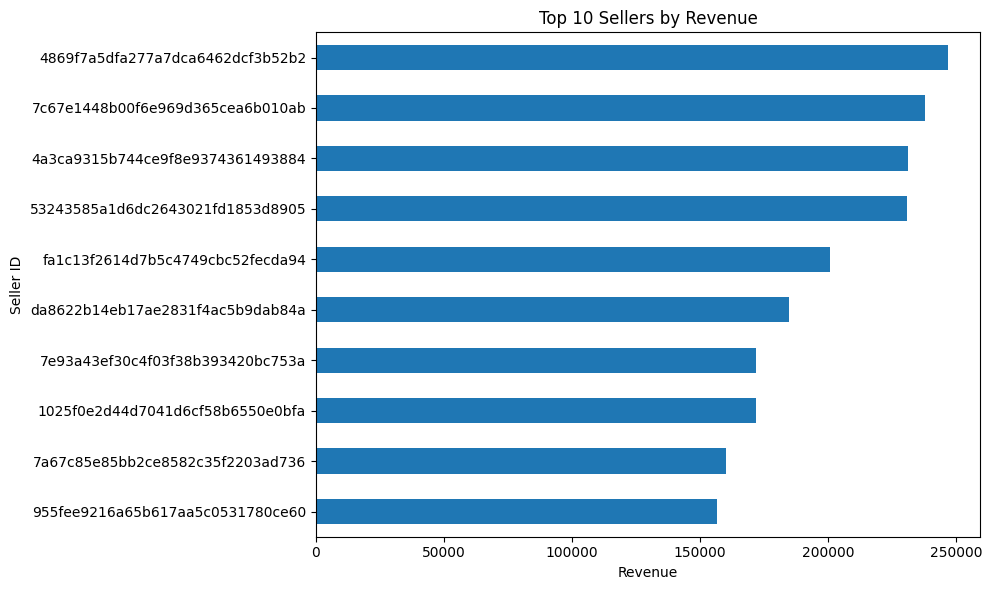

In [145]:
plt.figure(figsize=(10, 6))

top_sellers.plot(
    kind="barh",
    title="Top 10 Sellers by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

## 12.3 Top Sellers by Order Volume

Analyze which sellers handle the highest number of orders.

Comparing order volume with revenue helps identify whether seller performance
is driven by order quantity or higher-value products.

In [146]:
top_sellers_orders = (
    seller_summary[
        "total_orders"
    ]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

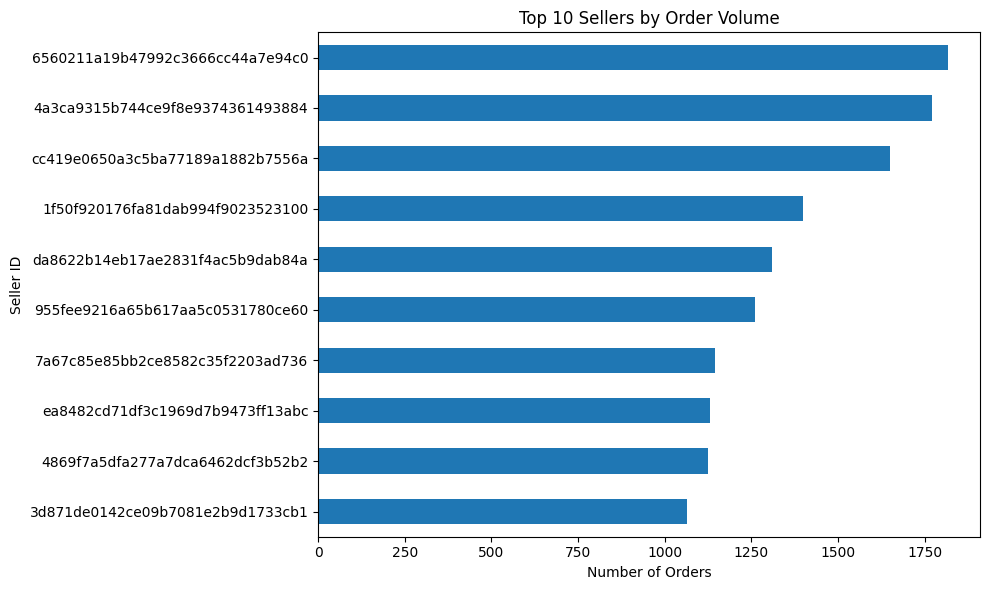

In [147]:
plt.figure(figsize=(10, 6))

top_sellers_orders.plot(
    kind="barh",
    title="Top 10 Sellers by Order Volume"
)

plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

## 12.4 Seller Customer Satisfaction

Analyze customer review scores associated with each seller.

Only sellers with at least 20 reviewed orders are included in the
customer satisfaction analysis. This reduces the influence of sellers
with very small review samples.

In [148]:
seller_reviews = (
    cleaned_orders[
        ["order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "seller_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

Aggregate:

In [149]:
seller_satisfaction = (
    seller_reviews
    .groupby("seller_id")
    .agg(
        total_reviews=("review_score", "count"),
        average_review_score=("review_score", "mean")
    )
    .round(2)
)

## 12.5 High Revenue but Low Customer Satisfaction

Identify sellers that generate significant revenue but have relatively low
customer satisfaction.

Sellers with fewer than 20 reviews are excluded to reduce the impact of
small sample sizes when evaluating customer satisfaction.

In [150]:
seller_performance = seller_summary.merge(
    seller_satisfaction,
    left_index=True,
    right_index=True,
    how="inner"
)

Filter:

In [151]:
high_revenue_low_satisfaction = (
    seller_performance[
        (seller_performance["total_reviews"] >= 20) &
        (seller_performance["average_review_score"] < 3.5)
    ]
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

high_revenue_low_satisfaction.head(10)

,total_orders,total_revenue,total_reviews,average_review_score
seller_id,,,,
7c67e1448b00f6e969d365cea6b010ab,973,237806.69,1358,3.35
712e6ed8aa4aa1fa65dab41fed5737e4,77,46149.82,85,3.47
2eb70248d66e0e3ef83659f71b244378,187,42046.73,195,2.81
88460e8ebdecbfecb5f9601833981930,246,36258.59,308,3.37
897060da8b9a21f655304d50fd935913,304,28258.33,413,3.47
710e3548e02bc1d2831dfc4f1b5b14d4,131,26111.91,136,3.46
8444e55c1f13cd5c179851e5ca5ebd00,92,23445.67,102,3.16
8e6d7754bc7e0f22c96d255ebda59eba,84,15793.35,132,3.03
a7f13822ceb966b076af67121f87b063,73,14980.43,83,3.49


## 12.6 Visualize High Revenue / Low Satisfaction Sellers
### Seller Revenue vs Customer Satisfaction

A scatter plot is used to identify sellers that combine high revenue with
relatively low customer satisfaction.

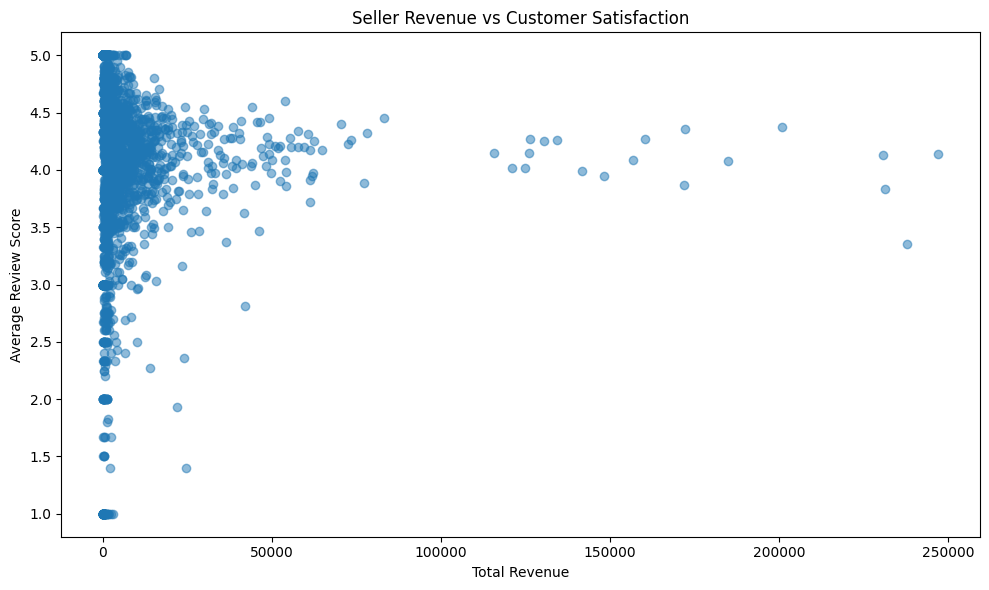

In [152]:
plt.figure(figsize=(10, 6))

plt.scatter(
    seller_performance["total_revenue"],
    seller_performance["average_review_score"],
    alpha=0.5
)

plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")
plt.title("Seller Revenue vs Customer Satisfaction")

plt.tight_layout()
plt.show()

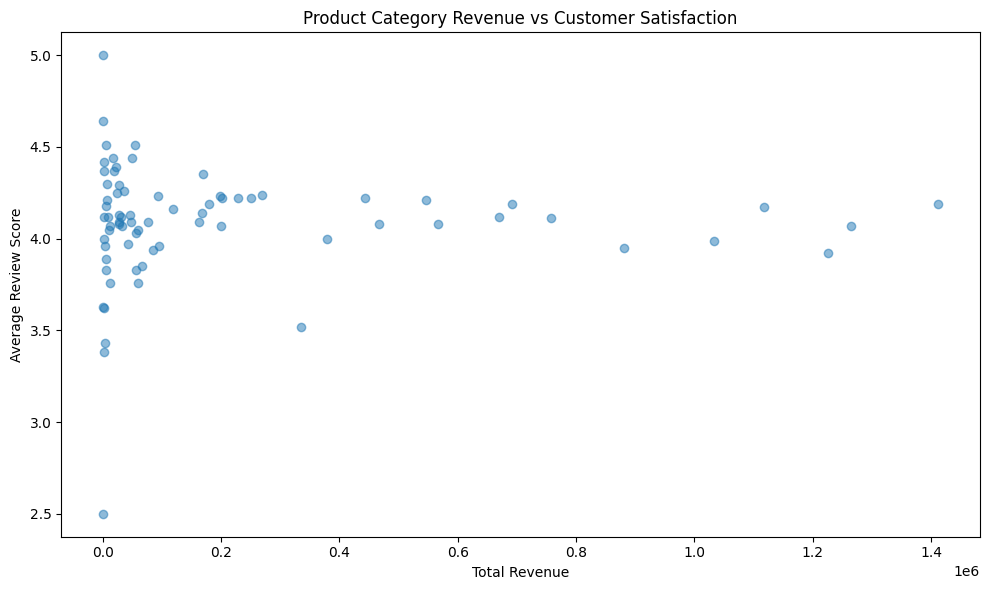

In [153]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_performance["total_revenue"],
    category_performance["average_review_score"],
    alpha=0.5
)

plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")
plt.title("Product Category Revenue vs Customer Satisfaction")

plt.tight_layout()
plt.show()

# 13. EDA Summary

The exploratory analysis examined the major dimensions of the Olist
e-commerce marketplace:

### Sales
- Monthly revenue trends were analyzed.
- Monthly order volume was compared with revenue.
- Average Order Value was calculated.
- Top product categories by revenue were identified.

### Delivery
- On-time and late delivery performance was analyzed.
- Average delivery and delay times were compared.
- States with higher late-delivery rates were identified.
- Delivery-time distributions and potential outliers were examined.
- The relationship between delivery performance and customer satisfaction
  was explored.

### Customer Satisfaction
- Overall customer review scores were analyzed.
- Review score distribution was examined.
- Product categories with high negative-review volumes were identified.
- High-revenue categories with relatively low satisfaction were investigated.

### Payment
- Payment method usage was analyzed.
- Revenue by payment method was compared.
- Single-payment and installment behavior was examined.

### Seller Performance
- Top sellers by revenue and order volume were identified.
- Seller customer satisfaction was analyzed.
- Sellers with high revenue but relatively low satisfaction were identified
  for further investigation.

The EDA findings will be used to support the final business analysis and
Power BI dashboard.